## This notebook contains some data preparation and modeling.

In this study, we used data from the "Investigation of Serial studies to Predict Your Therapeutic Response with Imaging And moLecular analysis 2" (I-SPY 2) clinical trial [[1](https://www.cancerimagingarchive.net/collection/ispy2/)]. Unfortunately, although the database contains information on 719 patients, we were only able to use 384, as they were the only ones that contained tumor size data, which we used in our prediction.

Due to time constraints, we were unable to extract tumor size data from the images; this requires further research.

Data preparation was performed outside of this notebook, so we store the pre-prepared file, `clean_data.tsv`, in the `data` folder. We added information about the intervals between MRI scans and made some predictions about tumor dynamics based on weekly changes in volume.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean_data.csv")

timepoints = [0, 4, 12, 24]
size_cols = [f"tumor_size_week_{t}" for t in timepoints]

display(df, df.columns)

,tumor_size_week_0,tumor_size_week_4,tumor_size_week_12,tumor_size_week_24,patient_id,arm,hr,her2,mp,pcr,...,menopausal_status,age,RR_4,RR_12,RR_24,slope_0_4,slope_4_12,slope_12_24,AUC,subtype
0,8.455051,0.487954,0.104259,0.031754,111881,paclitaxel_neratinib,1,1,1,1,...,premenopausal,37,0.942288,0.987669,0.996244,1.991774,0.047962,0.006042,21.070945,HR+/HER2+
1,44.886082,32.040192,30.457386,1.081564,139137,paclitaxel_abt_888_carboplatin,1,0,0,0,...,postmenopausal,54,0.286189,0.321451,0.975904,3.211473,0.197851,2.447985,593.076559,HR+/HER2-
2,7.729980,2.791406,0.537891,0.244336,627981,paclitaxel,0,0,0,1,...,postmenopausal,64,0.638886,0.930415,0.968391,1.234644,0.281689,0.024463,39.053319,TNBC
3,110.593870,66.855652,1.660144,2.499609,629210,paclitaxel_neratinib,1,0,0,0,...,premenopausal,40,0.395485,0.984989,0.977398,10.934554,8.149439,-0.069955,653.920748,HR+/HER2-
4,150.239370,75.192590,44.011676,48.265134,155171,paclitaxel_abt_888_carboplatin,1,0,0,0,...,premenopausal,50,0.499515,0.707056,0.678745,18.761695,3.897614,-0.354455,1481.341844,HR+/HER2-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,69.543521,0.930959,1.859743,1.569362,746265,paclitaxel_neratinib,1,0,0,0,...,premenopausal,35,0.986613,0.973258,0.977433,17.153140,-0.116098,0.024198,172.686403,HR+/HER2-
380,10.084901,5.363772,3.915301,11.113355,962153,paclitaxel_amg_386_trastuzumab,1,1,1,0,...,NaN,55,0.468138,0.611766,-0.101980,1.180282,0.181059,-0.599838,158.185579,HR+/HER2+
381,31.589209,3.867078,0.992725,0.755420,559263,paclitaxel,0,0,1,0,...,postmenopausal,64,0.877582,0.968574,0.976086,6.930533,0.359294,0.019775,100.840649,TNBC
382,5.413860,4.650367,1.898487,0.719865,666715,paclitaxel_ganetespib,1,0,0,0,...,premenopausal,32,0.141026,0.649328,0.867033,0.190873,0.343985,0.098218,62.033982,HR+/HER2-


Index(['tumor_size_week_0', 'tumor_size_week_4', 'tumor_size_week_12',
       'tumor_size_week_24', 'patient_id', 'arm', 'hr', 'her2', 'mp', 'pcr',
       'race', 'menopausal_status', 'age', 'RR_4', 'RR_12', 'RR_24',
       'slope_0_4', 'slope_4_12', 'slope_12_24', 'AUC', 'subtype'],
      dtype='object')

Pathological complete response `pCR` (also called pathologic complete remission) is a marker that helps to understand how well treatment is working or if the cancer will come back [[2](https://www.cancer.gov/publications/dictionaries/cancer-terms/def/pathologic-complete-response)].

In [2]:
pcr_table = (
    df
    .pivot_table(index=["subtype", "arm"], values="pcr",
                 aggfunc=["mean", "count"])
    .sort_values(("mean", "pcr"), ascending=False)
)

print(pcr_table.head(20))

                                                 mean count
                                                  pcr   pcr
subtype   arm                                              
HR-/HER2+ paclitaxel_mk2206_trastuzumab      1.000000     5
          paclitaxel_pertuzumab_trastuzumab  1.000000     8
TNBC      paclitaxel_pembrolizumab           0.777778     9
          paclitaxel_abt_888_carboplatin     0.666667    12
HR-/HER2+ paclitaxel_amg_386_trastuzumab     0.666667     3
TNBC      paclitaxel_ganetespib              0.647059    17
HR+/HER2+ tdm1_pertuzumab                    0.571429    14
TNBC      paclitaxel_mk2206                  0.500000    12
HR+/HER2+ paclitaxel_mk2206_trastuzumab      0.500000     4
HR-/HER2+ paclitaxel_trastuzumab             0.428571     7
TNBC      paclitaxel_ganitumab               0.333333    18
HR-/HER2+ tdm1_pertuzumab                    0.333333     3
HR+/HER2- paclitaxel_pembrolizumab           0.333333    18
HR+/HER2+ paclitaxel_pertuzumab_trastuzu

In [3]:
df['arm'].unique()

array(['paclitaxel_neratinib', 'paclitaxel_abt_888_carboplatin',
       'paclitaxel', 'paclitaxel_trastuzumab', 'paclitaxel_amg_386',
       'paclitaxel_ganetespib', 'paclitaxel_pembrolizumab',
       'paclitaxel_ganitumab', 'tdm1_pertuzumab', 'paclitaxel_mk2206',
       'paclitaxel_pertuzumab_trastuzumab',
       'paclitaxel_mk2206_trastuzumab', 'paclitaxel_amg_386_trastuzumab'],
      dtype=object)

In [4]:
mean_curves = (
    df
    .groupby(["subtype", "arm"])[size_cols]
    .mean()
    .reset_index()
)

arms = [
    'paclitaxel_neratinib', 'paclitaxel_abt_888_carboplatin',
    'paclitaxel', 'paclitaxel_trastuzumab', 'paclitaxel_amg_386',
    'paclitaxel_ganetespib', 'paclitaxel_pembrolizumab',
    'paclitaxel_ganitumab', 'tdm1_pertuzumab', 'paclitaxel_mk2206',
    'paclitaxel_pertuzumab_trastuzumab', 'paclitaxel_mk2206_trastuzumab',
    'paclitaxel_amg_386_trastuzumab'
]

subtypes = ['HR+/HER2+', 'HR+/HER2-', 'TNBC', 'HR-/HER2+']

rows = []
for subtype in subtypes:
    for arm in arms:
        subset = mean_curves[
            (mean_curves["subtype"] == subtype) &
            (mean_curves["arm"] == arm)
        ]
        if len(subset) > 0:   # фильтр
            rows.append(subset)

mean_dynamics = pd.concat(rows, ignore_index=True)
mean_dynamics


,subtype,arm,tumor_size_week_0,tumor_size_week_4,tumor_size_week_12,tumor_size_week_24
0,HR+/HER2+,paclitaxel_neratinib,39.623319,14.468640,4.850470,3.038090
1,HR+/HER2+,paclitaxel_trastuzumab,15.151351,7.296619,2.200591,1.689610
2,HR+/HER2+,tdm1_pertuzumab,16.799499,8.400590,3.260022,0.735112
3,HR+/HER2+,paclitaxel_pertuzumab_trastuzumab,8.092580,3.947013,0.626354,0.415332
4,HR+/HER2+,paclitaxel_mk2206_trastuzumab,21.313352,4.937402,1.806495,1.628843
5,HR+/HER2+,paclitaxel_amg_386_trastuzumab,19.247489,5.032528,3.581917,3.170446
6,HR+/HER2-,paclitaxel_neratinib,47.473447,18.679194,2.131827,1.204184
7,HR+/HER2-,paclitaxel_abt_888_carboplatin,31.901297,14.845671,7.008090,4.410969
8,HR+/HER2-,paclitaxel,30.941954,18.181653,6.740921,1.938104
9,HR+/HER2-,paclitaxel_amg_386,27.740607,16.663263,10.016871,4.250367


Let's visualise table above.

In [5]:
import matplotlib.pyplot as plt
def set_style() -> None:
    """
    Sets the custom styling for all matplotlib plots.
    """
    custom_style = {
        "axes.facecolor": "#F2F2F2",
        "axes.grid": False,
        "grid.alpha": 0.5,
        "axes.titlesize": 16,
        "axes.labelsize": 10,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.color": "282828",
        "ytick.color": "282828",
        "lines.linewidth": 2,
        "lines.color": "#8ACE00",
        "figure.figsize": (10, 5),
        "font.family": "Montserrat",
        "font.size": 14,
        "axes.labelcolor": "282828",
        "figure.edgecolor": "282828",
    }
    plt.rcParams.update(custom_style)

set_style()

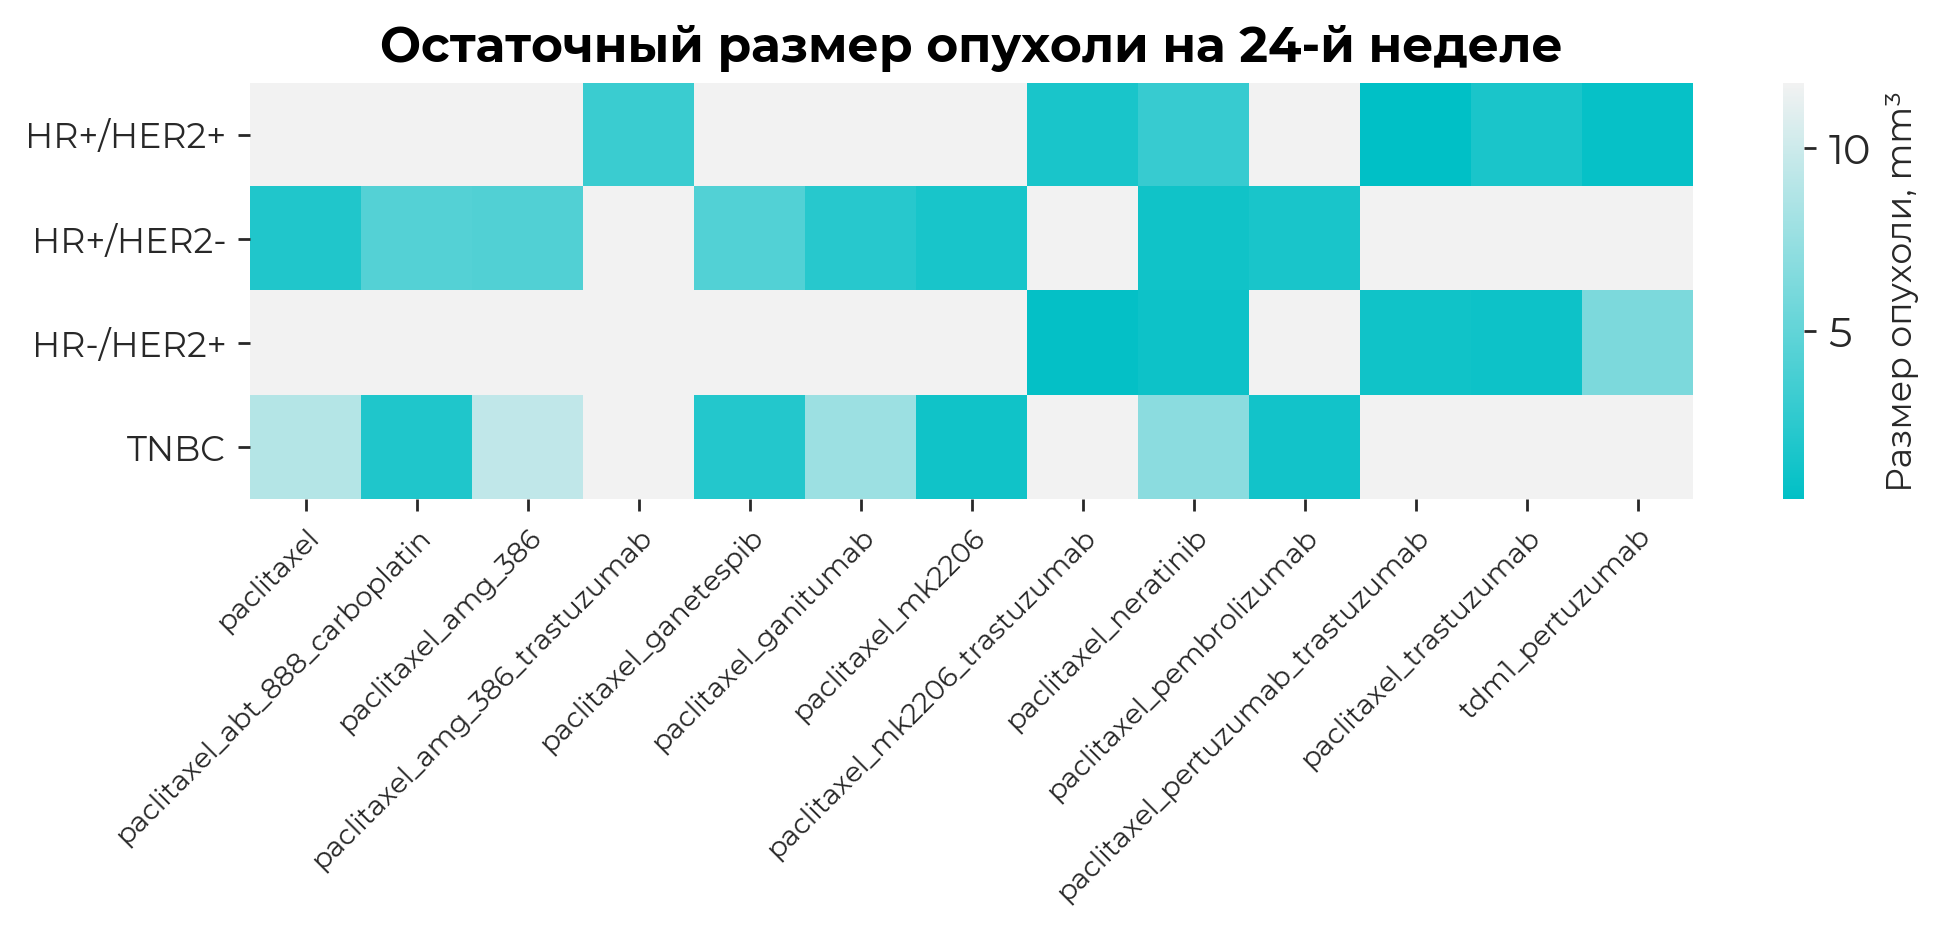

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pivot = df.pivot_table(index="subtype", columns="arm", values="tumor_size_week_24")

cmap = LinearSegmentedColormap.from_list("custom_cmap", ["#00C0C6", "#F2f2f2"])

width_px = 1067 * 2
height_px = 493 * 2
dpi = 250
fig_width = width_px / dpi
fig_height = height_px / dpi

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)

im = ax.imshow(pivot, aspect='auto', cmap=cmap)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    pivot.columns,
    rotation=45,
    ha='right',
    rotation_mode='anchor',
    fontsize=8
)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax)
cbar.outline.set_visible(False)

cbar.set_label("Размер опухоли, mm³")

ax.set_title("Остаточный размер опухоли на 24-й неделе", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

feature_cols_cat = ["subtype", "arm", "menopausal_status", "race"]
feature_cols_num = ["age", "hr", "her2", "mp"]

X = df[feature_cols_cat + feature_cols_num]
y = df["pcr"]

cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, feature_cols_cat),
        ("num", "passthrough", feature_cols_num),
    ]
)

log_reg = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="liblinear"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", 
        roc_auc_score(y_test, y_proba), "\n\n",
        classification_report(y_test, y_pred))

ROC-AUC: 0.7556360708534622 

               precision    recall  f1-score   support

           0       0.80      0.74      0.77        54
           1       0.48      0.57      0.52        23

    accuracy                           0.69        77
   macro avg       0.64      0.65      0.64        77
weighted avg       0.70      0.69      0.69        77



In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

feature_cols_cat = ["subtype", "arm", "menopausal_status", "race"]
feature_cols_num = ["age", "hr", "her2", "mp"]

X = df[feature_cols_cat + feature_cols_num]
y = df["pcr"]  # 0/1

cat_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
num_transformer = StandardScaler()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, feature_cols_cat),
        ("num", num_transformer, feature_cols_num),
    ]
)

hgb = HistGradientBoostingClassifier(
    max_depth=None,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    random_state=42
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", hgb)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_distributions = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__max_depth": [None, 2, 3, 4],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 1.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    n_jobs=-1,
    cv=cv,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Best ROC-AUC (CV):", search.best_score_)
print("Best params:", search.best_params_)

best_clf = search.best_estimator_

y_proba = best_clf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC-AUC (CV): 0.7138242894056848
Best params: {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 15, 'model__max_depth': None, 'model__learning_rate': 0.03, 'model__l2_regularization': 10.0}
Test ROC-AUC: 0.7435587761674718
              precision    recall  f1-score   support

           0       0.75      0.94      0.84        54
           1       0.67      0.26      0.38        23

    accuracy                           0.74        77
   macro avg       0.71      0.60      0.61        77
weighted avg       0.73      0.74      0.70        77



In [9]:
def recommend_regimens(patient_features, df, clf, top_k=3):
    """
    patient_features: dict без 'arm', например:
    {
        'subtype': 'TNBC',
        'age': 45,
        'menopausal_status': 'premenopausal',
        'race': 'white',
        'hr': 0,
        'her2': 0,
        'mp': 0,
    }
    """
    subtype = patient_features["subtype"]
    possible_arms = df[df["subtype"] == subtype]["arm"].unique()
    
    rows = []
    for arm in possible_arms:
        row = patient_features.copy()
        row["arm"] = arm
        rows.append(row)
    X_new = pd.DataFrame(rows)
    
    proba = clf.predict_proba(X_new)[:, 1]
    
    res = pd.DataFrame({
        "arm": possible_arms,
        "p_pcr": proba
    }).sort_values("p_pcr", ascending=False)
    
    return res.head(top_k)

patient = {
    "subtype": "TNBC",
    "age": 19,
    "menopausal_status": "premenopausal",
    "race": "white",
    "hr": 0,
    "her2": 0,
    "mp": 0,
}

recommend_regimens(patient, df, clf)

,arm,p_pcr
3,paclitaxel_pembrolizumab,0.680272
7,paclitaxel_abt_888_carboplatin,0.634031
6,paclitaxel_mk2206,0.509148


In [10]:
df.columns

Index(['tumor_size_week_0', 'tumor_size_week_4', 'tumor_size_week_12',
       'tumor_size_week_24', 'patient_id', 'arm', 'hr', 'her2', 'mp', 'pcr',
       'race', 'menopausal_status', 'age', 'RR_4', 'RR_12', 'RR_24',
       'slope_0_4', 'slope_4_12', 'slope_12_24', 'AUC', 'subtype'],
      dtype='object')

In [11]:
tumor_col_baseline   = "tumor_size_week_0"
tumor_col_w3         = "tumor_size_week_4"
tumor_col_w6         = "tumor_size_week_12"
tumor_col_pre_surg   = "tumor_size_week_24"


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

feature_cols_cat = ["subtype", "arm", "menopausal_status", "race"]
feature_cols_num = ["age", "hr", "her2", "mp", tumor_col_baseline]

target_cols = {
    "w3": tumor_col_w3,
    "w6": tumor_col_w6,
    "pre": tumor_col_pre_surg,
}

cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess_reg = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, feature_cols_cat),
        ("num", "passthrough", feature_cols_num),
    ]
)

def train_tumor_dynamics_models(df):
    models = {}
    
    df_use = df.copy()
    df_use = df_use.dropna(subset=[tumor_col_baseline])
    
    for key, target_col in target_cols.items():
        df_target = df_use.dropna(subset=[target_col])
        
        if df_target.empty:
            print(f"[WARN] Нет данных для таргета {target_col}, модель не будет обучена")
            continue
        
        X = df_target[feature_cols_cat + feature_cols_num]
        y = df_target[target_col].astype(float)

        y_log = np.log1p(y)
        
        X_train, X_val, y_train, y_val = train_test_split(
            X, y_log, test_size=0.2, random_state=42
        )
        
        gbr = GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
        
        pipe = Pipeline(steps=[
            ("preprocess", preprocess_reg),
            ("model", gbr),
        ])
        
        pipe.fit(X_train, y_train)
        
        y_pred_val_log = pipe.predict(X_val)
        y_pred_val = np.expm1(y_pred_val_log)
        y_val_real = np.expm1(y_val)
        
        mae = mean_absolute_error(y_val_real, y_pred_val)
        r2  = r2_score(y_val_real, y_pred_val)
        print(f"[{key}] {target_col}: MAE={mae:0.2f} мм, R²={r2:0.3f}, n={len(y_val_real)}")
        
        models[key] = pipe
    
    return models

tumor_models = train_tumor_dynamics_models(df)


[w3] tumor_size_week_4: MAE=11.52 мм, R²=0.380, n=77
[w6] tumor_size_week_12: MAE=10.38 мм, R²=0.056, n=77
[pre] tumor_size_week_24: MAE=6.19 мм, R²=-0.047, n=77


In [12]:
def predict_tumor_trajectory_for_patient(patient_features, df, tumor_models, arms=None):
    """
    patient_features: dict, например:
    {
        'subtype': 'TNBC',
        'age': 42,
        'menopausal_status': 'premenopausal',
        'race': 'white',
        'hr': 0,
        'her2': 0,
        'mp': 0,
        'tumor_size_baseline': 40.0,
    }
    """
    subtype = patient_features["subtype"]
    baseline_size = patient_features[tumor_col_baseline]
    
    if arms is None:
        arms = df[df["subtype"] == subtype]["arm"].dropna().unique()
    
    rows = []
    for arm in arms:
        feat = patient_features.copy()
        feat["arm"] = arm
        
        X_row = pd.DataFrame([feat])[feature_cols_cat + feature_cols_num]
        
        traj = [(0, baseline_size)]
        
        if "w3" in tumor_models:
            y3_log = tumor_models["w3"].predict(X_row)[0]
            y3 = float(np.expm1(y3_log))
            traj.append((3, y3))
        
        if "w6" in tumor_models:
            y6_log = tumor_models["w6"].predict(X_row)[0]
            y6 = float(np.expm1(y6_log))
            traj.append((6, y6))
        
        if "pre" in tumor_models:
            ypre_log = tumor_models["pre"].predict(X_row)[0]
            ypre = float(np.expm1(ypre_log))
            traj.append((18, ypre))
        
        for t, size in traj:
            rows.append({
                "arm": arm,
                "time_week": t,
                "tumor_size_pred_mm": size
            })
    
    return pd.DataFrame(rows)

In [13]:
top_k = 3
rec = recommend_regimens(patient, df, clf)
best_arms = rec["arm"].tolist()

traj_df = predict_tumor_trajectory_for_patient(
    patient_features={
        **patient,
        tumor_col_baseline: 15,
    },
    df=df,
    tumor_models=tumor_models,
    arms=best_arms
)

traj_df

,arm,time_week,tumor_size_pred_mm
0,paclitaxel_pembrolizumab,0,15.000000
1,paclitaxel_pembrolizumab,3,16.778619
2,paclitaxel_pembrolizumab,6,3.761983
3,paclitaxel_pembrolizumab,18,-0.155706
4,paclitaxel_abt_888_carboplatin,0,15.000000
5,paclitaxel_abt_888_carboplatin,3,11.395563
6,paclitaxel_abt_888_carboplatin,6,2.468184
7,paclitaxel_abt_888_carboplatin,18,-0.121803
8,paclitaxel_mk2206,0,15.000000
9,paclitaxel_mk2206,3,17.416859


                              arm     p_pcr
3        paclitaxel_pembrolizumab  0.680272
7  paclitaxel_abt_888_carboplatin  0.634031
6               paclitaxel_mk2206  0.509148
4           paclitaxel_ganetespib  0.478307
5            paclitaxel_ganitumab  0.371385


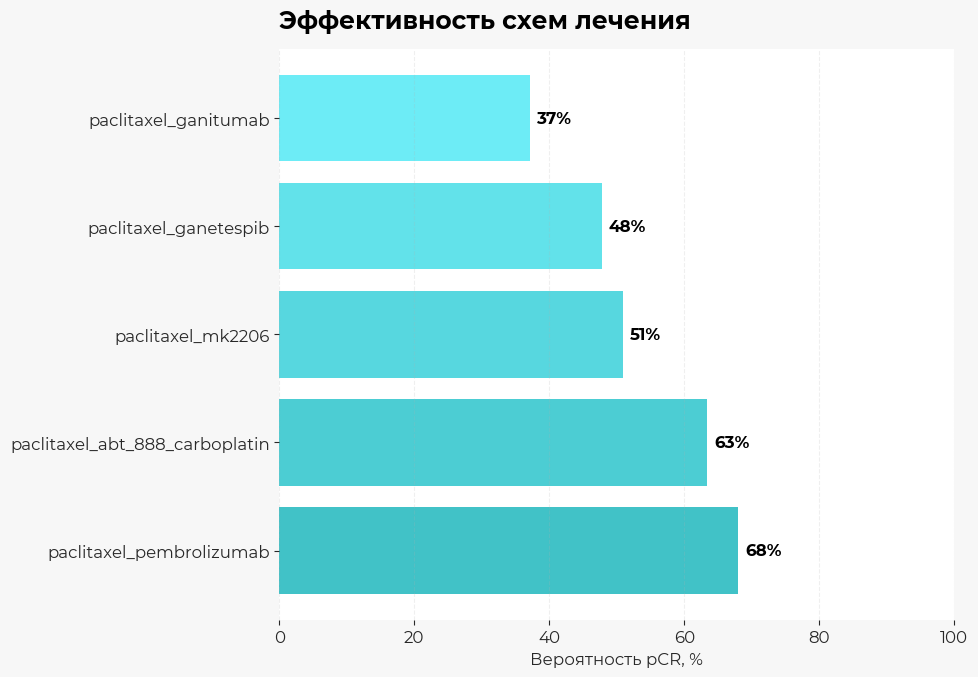

Ранжирование схем по ожидаемой вероятности pCR:
                               arm      p_pct
3        paclitaxel_pembrolizumab  68.027181
7  paclitaxel_abt_888_carboplatin  63.403110
6               paclitaxel_mk2206  50.914795
4           paclitaxel_ganetespib  47.830726
5            paclitaxel_ganitumab  37.138519 

Лучшая по модели схема: paclitaxel_pembrolizumab (68%). Минимальное значение в топ-5: paclitaxel_ganitumab (37%).


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regimen_effectiveness_all(recs_df, title="Эффективность схем лечения"):
    recs = recs_df.copy().sort_values("p_pcr", ascending=False)
    recs["p_pct"] = recs["p_pcr"] * 100

    arms = recs["arm"].tolist()
    values = recs["p_pct"].values
    n = len(arms)

    fig, ax = plt.subplots(figsize=(10, 1.2 * n + 1))

    base_color = np.array([65/255, 194/255, 199/255])
    light_color = np.array([109/255, 236/255, 246/255])
    colors = [
        base_color + (light_color - base_color) * (i / max(n-1, 1))
        for i in range(n)
    ]

    ax.barh(arms, values, color=colors)

    for i, (arm, val) in enumerate(zip(arms, values)):
        ax.text(
            val + 1,
            i,
            f"{val:.0f}%",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

    ax.set_xlim(0, 100)
    ax.set_xlabel("Вероятность pCR, %", fontsize=12)
    ax.set_title(title, fontsize=18, fontweight="bold", loc="left", pad=15)

    ax.set_facecolor("#ffffff")
    fig.patch.set_facecolor("#f7f7f7")

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="x", linestyle="--", alpha=0.2)
    plt.tight_layout()
    plt.show()

    best = recs.iloc[0]
    worst = recs.iloc[-1]
    print(
        "Ранжирование схем по ожидаемой вероятности pCR:\n",
        recs[["arm", "p_pct"]],
        "\n\nЛучшая по модели схема:",
        f"{best['arm']} ({best['p_pct']:.0f}%). "
        f"Минимальное значение в топ-{len(recs)}:",
        f"{worst['arm']} ({worst['p_pct']:.0f}%)."
    )

recs = recommend_regimens(patient, df, clf, top_k=5)
print(recs)
plot_regimen_effectiveness_all(recs)


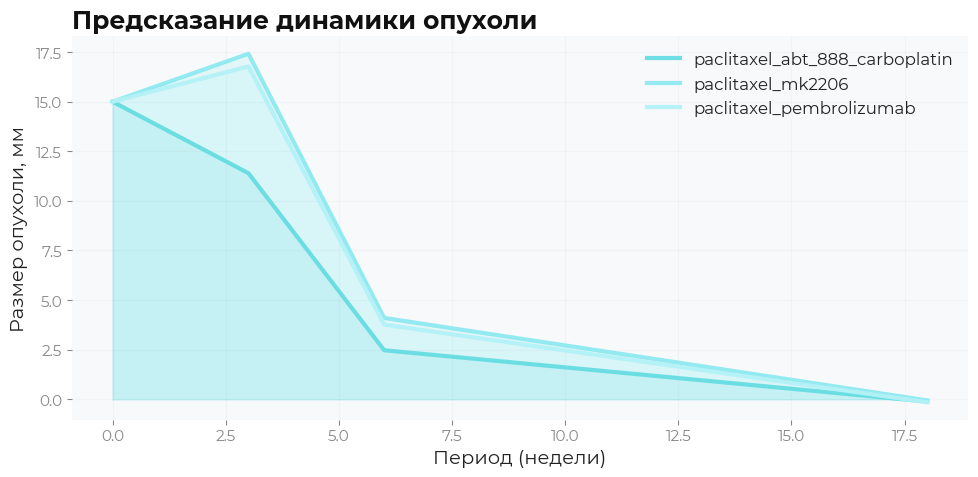

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tumor_trajectories(traj_df, title="Предсказание динамики опухоли"):
    COLORS = [
        "#66DDE2",
        "#8EEAF0",
        "#B3F2F7",
        "#4CC7CE",
        "#95E0E8",
    ]

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    ax.set_facecolor("#F7F9FA")
    ax.grid(True, linestyle="-", alpha=0.08)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.tick_params(colors="#888888", labelsize=11)

    for (arm, arm_df), color in zip(traj_df.groupby("arm"), COLORS):
        arm_df = arm_df.sort_values("time_week")

        plt.plot(
            arm_df["time_week"],
            arm_df["tumor_size_pred_mm"],
            color=color,
            linewidth=3,
            label=str(arm),
            alpha=0.95
        )

        plt.fill_between(
            arm_df["time_week"],
            arm_df["tumor_size_pred_mm"],
            color=color,
            alpha=0.20
        )

    plt.xlabel("Период (недели)", fontsize=14, color="#222")
    plt.ylabel("Размер опухоли, мм", fontsize=14, color="#222")
    plt.title(title, fontsize=18, fontweight="bold", loc="left", color="#111")

    leg = plt.legend(frameon=False, fontsize=12)
    for text in leg.get_texts():
        text.set_color("#222")

    plt.tight_layout()
    plt.show()

plot_tumor_trajectories(traj_df)